# PK/PD — IBM Backend Evaluation

Load a trained PK/PD model by folder name (uses the same inference logic as `dose_prediction.py`) and evaluate it on four PennyLane backends:

1. **Ideal** simulator (`default.qubit`)
2. **Aer** simulator (`qiskit.aer`)
3. **FakeTorino** noisy simulator (`qiskit.remote` + `FakeTorino`)
4. **Real IBM hardware** (`qiskit.remote` + `least_busy` backend)

Structure mirrors `IBM_Giang.ipynb`; model loading follows `dose_prediction.py`.


## 0. Imports

In [1]:
import os, json, math
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeTorino

# Reuse folder-name parsing + training-time constants from dose_prediction.py
from dose_prediction import infer_model_config, TIME_WINDOWS, HALF_LIVES
from Utils.data_loader import (
    build_feature_list, prepare_pkpd_data,
    prepare_lstm_sequences, collate_lstm_batch,
)


In [2]:
import logging                                                                    
logging.getLogger("qiskit").setLevel(logging.WARNING)                             
logging.getLogger("qiskit.transpiler").setLevel(logging.WARNING)                  
logging.getLogger("qiskit.passmanager").setLevel(logging.WARNING)

import os                                                                         
os.environ["QISKIT_SUPPRESS_PACKAGING_WARNINGS"] = "Y"                            
                                                    
import logging                                                                    
logging.getLogger("qiskit").setLevel(logging.ERROR)
for name in logging.root.manager.loggerDict:                                      
    if name.startswith("qiskit"):           
        logging.getLogger(name).setLevel(logging.ERROR)  

## 1. Config

In [3]:
import os                                                                         
# ============================================================
# EDIT THESE
# ============================================================
base_dir = "26_04_22_15_49_30_hqgnn_dual_stage_h256_combine"
csv_path       = "Data/UpdatedEstData.csv"
res_directory = f'Results/.IBM/{base_dir}'

file_directory = f'Results/{base_dir}'

plot_patient_ids = [9, 13, 26, 46]
DEVICE = torch.device("cpu")
   
os.makedirs(res_directory, exist_ok=True)                                         
os.makedirs(file_directory, exist_ok=True)


## 2. Infer model type, features and device size from the folder name + checkpoint

In [4]:
config = infer_model_config(file_directory)
checkpoint = torch.load(f"{file_directory}/model.pth", map_location="cpu")
mt = config['model_type']

# Dispatch the data pipeline on model family
if   mt in ('mlp', 'hqcnn', 'qnn'):   data_kind = 'tabular'
elif mt in ('lstm', 'hqlstm'):        data_kind = 'sequence'
elif mt in ('gnn',  'hqgnn'):         data_kind = 'graph'
else: raise ValueError(f"Unsupported model_type: {mt}")

# Input feature count from the first classical layer
if data_kind == 'tabular':
    n_features_model = next(v.shape[-1] for k, v in checkpoint.items()
                            if 'weight' in k and v.dim() == 2)
elif data_kind == 'sequence':
    n_features_model = next(v.shape[-1] for k, v in checkpoint.items()
                            if 'input_proj.weight' in k)
else:
    n_features_model = next(v.shape[-1] for k, v in checkpoint.items()
                            if 'pk_encoder.convs.0' in k and 'weight' in k)

# Reproduce the feature-flag detection used in dose_prediction.main()
base_n = len(build_feature_list(TIME_WINDOWS, HALF_LIVES))
if   n_features_model == base_n:      add_pk_summary, add_pk_cumulative = False, False
elif n_features_model == base_n + 5:  add_pk_summary, add_pk_cumulative = False, True
elif n_features_model == base_n + 6:  add_pk_summary, add_pk_cumulative = True,  False
elif n_features_model == base_n + 11: add_pk_summary, add_pk_cumulative = True,  True
else:
    raise ValueError(f"Cannot match feature count: model expects {n_features_model}, base={base_n}")

# Qubit count for the PennyLane device
if   mt in ('hqcnn', 'hqlstm', 'hqgnn'): n_qubits_dev = 8          # HQCNN circuit: fixed 8 wires
elif mt == 'qnn':                         n_qubits_dev = checkpoint['pk_model.q_weights'].shape[1]
else:                                     n_qubits_dev = 4          # classical — q_dev unused

has_quantum = mt in ('hqcnn', 'qnn', 'hqlstm', 'hqgnn')

print(f"Model:             {mt}  (data_kind={data_kind}, has_quantum={has_quantum})")
print(f"Mode / hidden:     {config['mode']} / {config['hidden_dim']}")
print(f"combine:           {config['combine']}")
print(f"pk_summary / cum:  {add_pk_summary} / {add_pk_cumulative}")
print(f"n_features:        {n_features_model}")
print(f"n_qubits_dev:      {n_qubits_dev}")
if not has_quantum:
    print(f"\n  NOTE: '{mt}' is purely classical — q_dev is ignored; all IBM backends give identical results.")


Inferred: model=hqgnn, hidden_dim=256, mode=dual_stage
Model:             hqgnn  (data_kind=graph, has_quantum=True)
Mode / hidden:     dual_stage / 256
combine:           True
pk_summary / cum:  True / True
n_features:        31
n_qubits_dev:      8


## 3. Prepare evaluation data

In [5]:
target_ids = {13, 26, 46}                                                                             


In [6]:


if data_kind == 'tabular':
    data = prepare_pkpd_data(
        csv_path=csv_path,
        test_size=0.1, val_size=0.1, random_state=1712,
        use_perkg=False,
        time_windows=TIME_WINDOWS, half_lives=HALF_LIVES, add_decay=True,
        stratified_split=True,
        normalize_data=False,
        add_pk_summary=add_pk_summary,
        add_pk_cumulative=add_pk_cumulative,
    )
    if len(target_ids):
        full_pk = {k: (np.vstack([data['train_pk'][k], data['val_pk'][k], data['test_pk'][k]])                   
                    if k == 'X' else                                                                          
                    np.concatenate([data['train_pk'][k], data['val_pk'][k], data['test_pk'][k]]))             
                for k in ('X','y','ids','times')}                                                             
        full_pd = {k: (np.vstack([data['train_pd'][k], data['val_pd'][k], data['test_pd'][k]])                   
                        if k == 'X' else                                                                          
                        np.concatenate([data['train_pd'][k], data['val_pd'][k], data['test_pd'][k]]))             
                    for k in ('X','y','ids','times')}                                                             
                                                                                                                
        mask_pk = np.isin(full_pk['ids'], list(target_ids))
        mask_pd = np.isin(full_pd['ids'], list(target_ids))                                                      
        all_pk = {k: v[mask_pk] for k, v in full_pk.items()}
        all_pd = {k: v[mask_pd] for k, v in full_pd.items()}    

    else:
        all_pk = {k: (np.vstack([data['val_pk'][k], data['test_pk'][k]])
                    if k == 'X' else
                    np.concatenate([data['val_pk'][k], data['test_pk'][k]]))
                for k in ('X','y','ids','times')}
        all_pd = {k: (np.vstack([data['val_pd'][k], data['test_pd'][k]])
                    if k == 'X' else
                    np.concatenate([data['val_pd'][k], data['test_pd'][k]]))
                for k in ('X','y','ids','times')}
        
    uniq_ids = sorted(set(all_pk['ids'].tolist()) | set(all_pd['ids'].tolist()))
    print(f"Tabular (val+test only): PK samples={len(all_pk['y'])}, PD samples={len(all_pd['y'])}, n_features={data['n_features']}")
    print(f"  Patient IDs: {uniq_ids}")

elif data_kind == 'sequence':
    data = prepare_lstm_sequences(
        csv_path=csv_path,
        test_size=0.1, val_size=0.1, random_state=1712,
        use_perkg=False,
        time_windows=TIME_WINDOWS, half_lives=HALF_LIVES, add_decay=True,
        stratified_split=True,
        combine=False,
        normalize_data=False,
        add_pk_summary=add_pk_summary,
        add_pk_cumulative=add_pk_cumulative,
    )
    if len(target_ids):
        all_sequences = [           
            s for s in (data['train_sequences'] + data['val_sequences'] + data['test_sequences'])                
            if s['id'] in target_ids                                                             
        ]   
    else:
        all_sequences = data['val_sequences'] + data['test_sequences']
        
    uniq_ids = sorted({s['id'] for s in all_sequences})
    print(f"Sequence (val+test only): {len(all_sequences)} patient sequences, n_features={data['n_features']}")
    print(f"  Patient IDs: {uniq_ids}")

else:  # graph
    from types import SimpleNamespace
    from Utils.data_process import prepare_gnn_data
    gnn_args = SimpleNamespace(
        csv_path='UpdatedEstData',
        time_windows=TIME_WINDOWS, half_lives=HALF_LIVES,
        add_decay=True, use_perkg=False,
        add_pk_summary=add_pk_summary, add_pk_cumulative=add_pk_cumulative,
        no_placebo=False, stratified_split=True,
        test_size=0.1, val_size=0.1, random_seed=1712,
        combine=False, normalize_data=False,
    )
    data = prepare_gnn_data(gnn_args)

    if len(target_ids):
        full_graphs = data['train_data'] + data['val_data'] + data['test_data']
        all_graphs = [g for g in full_graphs if int(g.patient_id) in target_ids]
    else:
        all_graphs = data['val_data'] + data['test_data']
    # all_graphs = data['val_data'] + data['test_data']
    uniq_ids = sorted({int(getattr(g, 'patient_id', getattr(g, 'id', -1))) for g in all_graphs})
    print(f"Graph (val+test only): {len(all_graphs)} graphs, feature_dim={data['feature_dim']}")
    print(f"  Patient IDs: {uniq_ids}")


|INFO - Preparing GNN graph data...


Loaded data: 2820 total records
  Observations: 2064
  Dosing events: 756


|INFO - Total features (shared with MLP): 31


Feature engineering complete:
  Time windows: [24, 48, 72, 96, 120, 144, 168]
  Decay half-lives: [24, 48, 72]
  PK patient features: 36/48 patients have PK data
  PK cumulative features: 36/48 patients have PK data

Dose-stratified split (n_bins=4):
  (0.099, 0.233]: 12 subjects -> 10 train, 1 val, 1 test
  (0.233, 0.533]: 12 subjects -> 10 train, 1 val, 1 test
  (0.533, 1.0]: 12 subjects -> 10 train, 1 val, 1 test
  placebo: 12 subjects -> 10 train, 1 val, 1 test


|INFO - Created 48 patient graphs
|INFO - Train: 40, Val: 4, Test: 4


Graph (val+test only): 3 graphs, feature_dim=31
  Patient IDs: [13, 26, 46]


## 4. Model builder (threads `q_dev` into quantum families)

For `hqcnn`, `qnn`, `hqlstm`, `hqgnn` we rebuild the model with `q_dev` passed in — everything else mirrors `dose_prediction.load_model`. Classical families (`mlp`, `lstm`, `gnn`) just delegate to `dose_prediction.load_model`.

In [7]:
def build_model(q_dev):
    mt     = config['model_type']
    mode   = config['mode']
    hdim   = config['hidden_dim']
    n_feat = n_features_model

    if mt == 'hqcnn':
        from Models.quantum import HierarchicalHQCNN
        n_layers = sum(1 for k in checkpoint
                       if 'pk_model.qlayers' in k and 'weights_0' in k)
        model = HierarchicalHQCNN(
            pk_input_dim=n_feat, pd_input_dim=n_feat,
            num_layers=max(n_layers, 1), mode=mode, q_dev=q_dev,
        )
        model.load_state_dict(checkpoint)

    elif mt == 'qnn':
        from Models.quantum import HierarchicalQNN
        n_ql, n_qb, _ = checkpoint['pk_model.q_weights'].shape
        model = HierarchicalQNN(
            pk_input_dim=n_feat, pd_input_dim=n_feat,
            n_qubits=n_qb, n_qlayers=n_ql, mode=mode, q_dev=q_dev,
        )
        model.load_state_dict(checkpoint)

    elif mt == 'hqlstm':
        from Models.quantum import HQLSTM
        using_hqcnn = 'pk_encoder.predictor.clayer_1.weight' in checkpoint
        q_w = checkpoint.get('pk_encoder.predictor.q_weights')
        if q_w is not None and not using_hqcnn:
            n_ql, n_qb, _ = q_w.shape
        else:
            n_ql, n_qb = 1, 4
        model = HQLSTM(
            input_dim=n_feat, hidden_dim=hdim, mode=mode,
            n_qlayers=n_ql, n_qubits=n_qb, using_hqcnn=using_hqcnn, q_dev=q_dev,
        )
        model.load_state_dict(checkpoint)

    elif mt == 'hqgnn':
        from Models.quantum import HQGNN
        conv_keys = [k for k in checkpoint if 'pk_encoder.convs.0' in k and 'weight' in k]
        feat_dim  = checkpoint[conv_keys[0]].shape[-1] if conv_keys else n_feat
        using_hqcnn = 'pd_decoder.pd_predictor.clayer_1.weight' in checkpoint
        q_w = checkpoint.get('pd_decoder.pd_predictor.q_weights')
        if q_w is not None and not using_hqcnn:
            n_ql, n_qb, _ = q_w.shape
        else:
            n_ql, n_qb = 1, 4
        model = HQGNN(
            feature_dim=feat_dim, hidden_dim=hdim,
            n_qlayers=n_ql, n_qubits=n_qb, using_hqcnn=using_hqcnn, q_dev=q_dev,
        )
        model.load_state_dict(checkpoint)

    else:
        # Classical — q_dev unused; fall through to dose_prediction.load_model
        from dose_prediction import load_model
        model = load_model(file_directory, config, n_feat)

    model.eval()
    total = sum(p.numel() for p in model.parameters())
    print(f"  Loaded {mt}: {total:,} parameters")
    return model


## 5. Evaluation helpers

In [8]:
def _metrics(y_true, y_pred):
    return {
        'MSE':  float(mean_squared_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'R2':   float(r2_score(y_true, y_pred)),
    }


def _eval_tabular(model, X, which, device, batch_size=32):
    X_t = torch.as_tensor(X, dtype=torch.float32, device=device)
    preds = []
    for start in range(0, X_t.shape[0], batch_size):
        chunk = X_t[start:start + batch_size]
        if which == 'pk':
            out = model(x_pk=chunk)
            preds.append(out['pk'].cpu().numpy().flatten())
        else:
            out = model(x_pk=chunk, x_pd=chunk)
            preds.append(out['pd'].cpu().numpy().flatten())
    return np.concatenate(preds) if preds else np.zeros(0)


def _eval_sequence(model, sequences, device, batch_size=8):
    pk_preds, pk_targets, pk_ids, pk_times = [], [], [], []
    pd_preds, pd_targets, pd_ids, pd_times = [], [], [], []
    for start in range(0, len(sequences), batch_size):
        batch_seqs = sequences[start:start + batch_size]
        batch = collate_lstm_batch(batch_seqs, device)
        if 'X_pk' not in batch or 'X_pd' not in batch:
            continue
        out = model(
            x_pk=batch['X_pk'], x_pd=batch['X_pd'],
            lengths_pk=batch['lengths_pk'], lengths_pd=batch['lengths_pd'],
        )
        m_pk = batch['mask_pk'].cpu().numpy()
        m_pd = batch['mask_pd'].cpu().numpy()
        pk_p = out['pk'].squeeze(-1).cpu().numpy()
        pd_p = out['pd'].squeeze(-1).cpu().numpy()
        pk_y = batch['y_pk'].cpu().numpy()
        pd_y = batch['y_pd'].cpu().numpy()
        for i, s in enumerate(batch_seqs):
            if 'pk' in s:
                m = m_pk[i][:pk_p.shape[1]]
                pk_preds.append(pk_p[i][m])
                pk_targets.append(pk_y[i][m])
                pk_ids.append(np.full(int(m.sum()), s['id']))
                pk_times.append(s['pk']['times'][:int(m.sum())])
            if 'pd' in s:
                m = m_pd[i][:pd_p.shape[1]]
                pd_preds.append(pd_p[i][m])
                pd_targets.append(pd_y[i][m])
                pd_ids.append(np.full(int(m.sum()), s['id']))
                pd_times.append(s['pd']['times'][:int(m.sum())])
    def _cat(x): return np.concatenate(x) if x else np.zeros(0)
    return (
        {'preds': _cat(pk_preds), 'targets': _cat(pk_targets), 'ids': _cat(pk_ids), 'times': _cat(pk_times)},
        {'preds': _cat(pd_preds), 'targets': _cat(pd_targets), 'ids': _cat(pd_ids), 'times': _cat(pd_times)},
    )


def _eval_graph(model, graphs, device, batch_size=8):
    from torch_geometric.loader import DataLoader as PyGDataLoader
    loader = PyGDataLoader(graphs, batch_size=batch_size, shuffle=False)
    pk_preds, pk_targets, pk_ids, pk_times = [], [], [], []
    pd_preds, pd_targets, pd_ids, pd_times = [], [], [], []
    for batch in loader:
        batch = batch.to(device)
        pd_pred, pk_pred = model(batch, return_pk=True)
        pk_mask = batch.pk_mask.cpu().numpy().astype(bool)
        pd_mask = batch.pd_mask.cpu().numpy().astype(bool)
        pk_preds.append(pk_pred.squeeze(-1).cpu().numpy()[pk_mask])
        pk_targets.append(batch.pk_targets.cpu().numpy()[pk_mask])
        pd_preds.append(pd_pred.squeeze(-1).cpu().numpy()[pd_mask])
        pd_targets.append(batch.pd_targets.cpu().numpy()[pd_mask])
        for attr, sink in (('pk_ids', pk_ids), ('pd_ids', pd_ids),
                           ('pk_times', pk_times), ('pd_times', pd_times)):
            if hasattr(batch, attr):
                vec = getattr(batch, attr).cpu().numpy()
                mask = pk_mask if attr.startswith('pk') else pd_mask
                sink.append(vec[mask])
    def _cat(x): return np.concatenate(x) if x else np.zeros(0)
    return (
        {'preds': _cat(pk_preds), 'targets': _cat(pk_targets), 'ids': _cat(pk_ids), 'times': _cat(pk_times)},
        {'preds': _cat(pd_preds), 'targets': _cat(pd_targets), 'ids': _cat(pd_ids), 'times': _cat(pd_times)},
    )


@torch.no_grad()
def evaluate_pkpd(model, device, save_path=None):
    model.eval()
    if data_kind == 'tabular':
        pk_preds = _eval_tabular(model, all_pk['X'], which='pk', device=device)
        pd_preds = _eval_tabular(model, all_pd['X'], which='pd', device=device)
        pk_bundle = {'preds': pk_preds, 'targets': all_pk['y'], 'ids': all_pk['ids'], 'times': all_pk['times']}
        pd_bundle = {'preds': pd_preds, 'targets': all_pd['y'], 'ids': all_pd['ids'], 'times': all_pd['times']}
    elif data_kind == 'sequence':
        pk_bundle, pd_bundle = _eval_sequence(model, all_sequences, device=device)
    else:
        pk_bundle, pd_bundle = _eval_graph(model, all_graphs, device=device)

    metrics = {
        'pk': _metrics(pk_bundle['targets'], pk_bundle['preds']),
        'pd': _metrics(pd_bundle['targets'], pd_bundle['preds']),
    }
    result = {'metrics': metrics, 'pk': pk_bundle, 'pd': pd_bundle}

    if save_path:
        with open(save_path, 'w') as f:
            json.dump({
                'metrics': metrics,
                'pk_preds':  pk_bundle['preds'].tolist(),
                'pk_targets': pk_bundle['targets'].tolist(),
                'pd_preds':  pd_bundle['preds'].tolist(),
                'pd_targets': pd_bundle['targets'].tolist(),
            }, f, indent=2)
        print(f"  Saved results to {save_path}")
    return result


def print_metrics(name, metrics):
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"  PK - MSE: {metrics['pk']['MSE']:.4f}, RMSE: {metrics['pk']['RMSE']:.4f}, "
          f"MAE: {metrics['pk']['MAE']:.4f}, R2: {metrics['pk']['R2']:.4f}")
    print(f"  PD - MSE: {metrics['pd']['MSE']:.4f}, RMSE: {metrics['pd']['RMSE']:.4f}, "
          f"MAE: {metrics['pd']['MAE']:.4f}, R2: {metrics['pd']['R2']:.4f}")


In [9]:
# -----------------------------------------------------------------------------
# Incremental evaluator: save JSON sau mỗi patient. Rerun -> skip patient đã save.
# -----------------------------------------------------------------------------
import os, json, torch, numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch_geometric.loader import DataLoader as PyGDataLoader

def _atomic_save(path, obj):
    tmp = path + '.tmp'
    with open(tmp, 'w') as f:
        json.dump(obj, f, indent=1)
    os.replace(tmp, path)

def _metrics_of(y, p):
    y, p = np.asarray(y), np.asarray(p)
    if len(y) == 0:
        return None
    return {
        'MSE':  float(mean_squared_error(y, p)),
        'RMSE': float(np.sqrt(mean_squared_error(y, p))),
        'MAE':  float(mean_absolute_error(y, p)),
        'R2':   float(r2_score(y, p)),
    }

@torch.no_grad()
def evaluate_pkpd_incremental(model, device, save_path, resume=True):
    model.eval()
    state = {
        'done_ids': [],
        'pk_preds': [], 'pk_targets': [], 'pk_ids': [], 'pk_times': [],
        'pd_preds': [], 'pd_targets': [], 'pd_ids': [], 'pd_times': [],
    }
    if resume and os.path.exists(save_path):
        with open(save_path) as f:
            loaded = json.load(f)
        if 'done_ids' in loaded:
            state = loaded
            print(f"Resume: {len(state['done_ids'])} done: {state['done_ids']}")

    done = set(state['done_ids'])

    if data_kind == 'graph':
        remaining = [g for g in all_graphs if int(g.patient_id) not in done]
        print(f"Remaining graphs: {len(remaining)}/{len(all_graphs)}")
        for g in remaining:
            pid = int(g.patient_id)
            batch = next(iter(PyGDataLoader([g], batch_size=1, shuffle=False))).to(device)
            pd_pred, pk_pred = model(batch, return_pk=True)
            pkm = batch.pk_mask.cpu().numpy().astype(bool)
            pdm = batch.pd_mask.cpu().numpy().astype(bool)
            t   = batch.times.cpu().numpy()
            state['pk_preds']   += pk_pred.squeeze(-1).cpu().numpy()[pkm].tolist()
            state['pk_targets'] += batch.pk_targets.cpu().numpy()[pkm].tolist()
            state['pk_ids']     += [pid] * int(pkm.sum())
            state['pk_times']   += t[pkm].tolist()
            state['pd_preds']   += pd_pred.squeeze(-1).cpu().numpy()[pdm].tolist()
            state['pd_targets'] += batch.pd_targets.cpu().numpy()[pdm].tolist()
            state['pd_ids']     += [pid] * int(pdm.sum())
            state['pd_times']   += t[pdm].tolist()
            state['done_ids'].append(pid)
            state['metrics'] = {
                'pk': _metrics_of(state['pk_targets'], state['pk_preds']),
                'pd': _metrics_of(state['pd_targets'], state['pd_preds']),
            }
            _atomic_save(save_path, state)
            print(f"  [saved] patient {pid}: {int(pkm.sum())} PK, {int(pdm.sum())} PD")

    elif data_kind == 'sequence':
        remaining = [s for s in all_sequences if int(s['id']) not in done]
        print(f"Remaining sequences: {len(remaining)}/{len(all_sequences)}")
        for s in remaining:
            pid = int(s['id'])
            batch = collate_lstm_batch([s], device)
            if 'X_pk' in batch and 'X_pd' in batch:
                out = model(x_pk=batch['X_pk'], x_pd=batch['X_pd'],
                            lengths_pk=batch['lengths_pk'], lengths_pd=batch['lengths_pd'])
                pk_p = out['pk'].squeeze(-1).cpu().numpy()[0]
                pd_p = out['pd'].squeeze(-1).cpu().numpy()[0]
                m_pk = batch['mask_pk'].cpu().numpy()[0][:pk_p.shape[0]]
                m_pd = batch['mask_pd'].cpu().numpy()[0][:pd_p.shape[0]]
                if 'pk' in s:
                    state['pk_preds']   += pk_p[m_pk].tolist()
                    state['pk_targets'] += batch['y_pk'].cpu().numpy()[0][m_pk].tolist()
                    state['pk_ids']     += [pid] * int(m_pk.sum())
                    state['pk_times']   += list(np.asarray(s['pk']['times'])[:int(m_pk.sum())])
                if 'pd' in s:
                    state['pd_preds']   += pd_p[m_pd].tolist()
                    state['pd_targets'] += batch['y_pd'].cpu().numpy()[0][m_pd].tolist()
                    state['pd_ids']     += [pid] * int(m_pd.sum())
                    state['pd_times']   += list(np.asarray(s['pd']['times'])[:int(m_pd.sum())])
            state['done_ids'].append(pid)
            state['metrics'] = {
                'pk': _metrics_of(state['pk_targets'], state['pk_preds']),
                'pd': _metrics_of(state['pd_targets'], state['pd_preds']),
            }
            _atomic_save(save_path, state)
            print(f"  [saved] patient {pid}")

    else:
        raise NotImplementedError("Tabular chưa implement — dùng evaluate_pkpd cũ.")

    return {
        'metrics': state['metrics'],
        'pk': {'preds': np.asarray(state['pk_preds']),
               'targets': np.asarray(state['pk_targets']),
               'ids':     np.asarray(state['pk_ids']),
               'times':   np.asarray(state['pk_times'])},
        'pd': {'preds': np.asarray(state['pd_preds']),
               'targets': np.asarray(state['pd_targets']),
               'ids':     np.asarray(state['pd_ids']),
               'times':   np.asarray(state['pd_times'])},
    }

## 6. Ideal simulator (`default.qubit`)

In [10]:
dev_ideal = qml.device("default.qubit", wires=n_qubits_dev)
model_ideal = build_model(dev_ideal)

print("Running Ideal evaluation...")
results_ideal = evaluate_pkpd(
    model_ideal, DEVICE,
    save_path=f"{res_directory}/ibm_ideal_results.json",
)
print_metrics("Ideal (default.qubit)", results_ideal['metrics'])


  Loaded hqgnn: 496,700 parameters
Running Ideal evaluation...
  Saved results to Results/.IBM/26_04_22_15_49_30_hqgnn_dual_stage_h256_combine/ibm_ideal_results.json

Ideal (default.qubit)
  PK - MSE: 0.2953, RMSE: 0.5434, MAE: 0.2828, R2: 0.9097
  PD - MSE: 6.5795, RMSE: 2.5651, MAE: 1.8493, R2: 0.7405


## 7. Aer simulator

In [11]:
dev_aer = qml.device("qiskit.aer", wires=n_qubits_dev)
model_aer = build_model(dev_aer)

dev_aer.tracker.active = True
dev_aer.tracker.reset()

print("Running Aer evaluation...")
results_aer = evaluate_pkpd(
    model_aer, DEVICE,
    save_path=f"{res_directory}/ibm_aer_results.json",
)
print_metrics("Aer Simulator", results_aer['metrics'])
print(f"  Executions: {dev_aer.tracker.totals.get('executions', 0)}")
print(f"  Shots:      {dev_aer.tracker.totals.get('shots', 0)}")


/home/wine-4/miniconda3/envs/quantum_challenge/lib/python3.10/site-packages/pennylane/__init__.py:215: PennyLaneDeprecationWarning: pennylane.DeviceError is no longer accessible at top-level                 and must be imported as pennylane.exceptions.DeviceError.                     Support for top-level access will be removed in v0.43.
  warnings.warn(
/home/wine-4/miniconda3/envs/quantum_challenge/lib/python3.10/site-packages/pennylane/operation.py:2631: PennyLaneDeprecationWarning: AnyWires is deprecated and will be removed in v0.43.  If your operation accepts any number of wires, set num_wires=None instead.
  warnings.warn(
/home/wine-4/miniconda3/envs/quantum_challenge/lib/python3.10/site-packages/qiskit_ibm_provider/api/session.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  impo

  Loaded hqgnn: 496,700 parameters
Running Aer evaluation...
  Saved results to Results/.IBM/26_04_22_15_49_30_hqgnn_dual_stage_h256_combine/ibm_aer_results.json

Aer Simulator
  PK - MSE: 0.2953, RMSE: 0.5434, MAE: 0.2828, R2: 0.9097
  PD - MSE: 6.5793, RMSE: 2.5650, MAE: 1.8493, R2: 0.7405
  Executions: 147
  Shots:      150528


## 8. FakeTorino (noisy simulator)

In [12]:
# # Minimal fix: pennylane_qiskit transpile 4-qubit circuit lên physical
# # layout của FakeTorino (133 qubits) nhưng không apply_layout lên observable
# # → Estimator raise qubit mismatch. Patch ở tầng class để fix.
# import numpy as _np
# from pennylane_qiskit.qiskit_device import QiskitDevice as _QD
# from pennylane_qiskit.converter import circuit_to_qiskit as _c2q, mp_to_pauli as _mp2p
# from qiskit_ibm_runtime import EstimatorV2 as _Estimator

# def _estimator_with_layout(self, circuit, session):
#     qcirc = [_c2q(circuit, self.num_wires, diagonalize=False, measure=False)]
#     estimator = _Estimator(session=session)  # giữ nguyên path cũ
#     pauli_obs = [_mp2p(mp, self.num_wires) for mp in circuit.measurements]
#     compiled = self.compile_circuits(qcirc)
#     layout = getattr(compiled[0], 'layout', None)
#     if layout is not None:
#         pauli_obs = [p.apply_layout(layout) for p in pauli_obs]
#     estimator.options.update(**self._kwargs)
#     result = estimator.run(
#         [(compiled[0], pauli_obs)],
#         precision=_np.sqrt(1 / circuit.shots.total_shots) if circuit.shots else None,
#     ).result()
#     self._current_job = result
#     return self._process_estimator_job(circuit.measurements, result)

# _QD._execute_estimator = _estimator_with_layout
# print("[OK] Estimator layout fix áp dụng cho tất cả QiskitDevice (Torino + real).")


In [13]:
backend_fake = FakeTorino()
dev_torino = qml.device("qiskit.remote", wires=n_qubits_dev, backend=backend_fake)
model_torino = build_model(dev_torino)

dev_torino.tracker.active = True
dev_torino.tracker.reset()

print("Running FakeTorino evaluation (noisy simulation)...")
results_torino = evaluate_pkpd(
    model_torino, DEVICE,
    save_path=f"{res_directory}/ibm_torino_results.json",
)
print_metrics("FakeTorino", results_torino['metrics'])
print(f"  Executions: {dev_torino.tracker.totals.get('executions', 0)}")
print(f"  Shots:      {dev_torino.tracker.totals.get('shots', 0)}")


  Loaded hqgnn: 496,700 parameters
Running FakeTorino evaluation (noisy simulation)...
  Saved results to Results/.IBM/26_04_22_15_49_30_hqgnn_dual_stage_h256_combine/ibm_torino_results.json

FakeTorino
  PK - MSE: 0.2953, RMSE: 0.5434, MAE: 0.2828, R2: 0.9097
  PD - MSE: 6.7672, RMSE: 2.6014, MAE: 1.8742, R2: 0.7331
  Executions: 147
  Shots:      150528


In [58]:
# import json
# import numpy as np

# # ---- Load results từ JSON đã lưu ----------------------------------
# def load_results(path):
#     with open(path) as f:
#         d = json.load(f)
#     return {
#         'metrics': d['metrics'],
#         'pk': {'preds':   np.asarray(d['pk_preds'],   dtype=float),
#                'targets': np.asarray(d['pk_targets'], dtype=float)},
#         'pd': {'preds':   np.asarray(d['pd_preds'],   dtype=float),
#                'targets': np.asarray(d['pd_targets'], dtype=float)},
#     }

# results_ideal  = load_results(f"{res_directory}/ibm_ideal_results.json")
# results_aer    = load_results(f"{res_directory}/ibm_aer_results.json")
# results_torino = load_results(f"{res_directory}/ibm_torino_results.json")

# # ---- Rebuild `all_*` the same way cell 10 does (val+test only) -------
# # (JSON was produced with this slice — use the same slice here or
# #  sanity check below will fail. Also makes this cell idempotent.)
# if data_kind == 'sequence':
#     all_sequences = data['val_sequences'] + data['test_sequences']
# elif data_kind == 'tabular':
#     all_pk = {k: (np.vstack([data['val_pk'][k], data['test_pk'][k]])
#                   if k == 'X' else
#                   np.concatenate([data['val_pk'][k], data['test_pk'][k]]))
#               for k in ('X', 'y', 'ids', 'times')}
#     all_pd = {k: (np.vstack([data['val_pd'][k], data['test_pd'][k]])
#                   if k == 'X' else
#                   np.concatenate([data['val_pd'][k], data['test_pd'][k]]))
#               for k in ('X', 'y', 'ids', 'times')}
# elif data_kind == 'graph':
#     all_graphs = data['val_data'] + data['test_data']

# # ---- Dựng lại ids/times theo đúng thứ tự với lúc eval ----------------
# if data_kind == 'sequence':
#     pk_ids, pk_times, pd_ids, pd_times = [], [], [], []
#     for s in all_sequences:
#         if 'pk' in s:
#             n = len(s['pk']['times'])
#             pk_ids.append(np.full(n, s['id']))
#             pk_times.append(np.asarray(s['pk']['times']))
#         if 'pd' in s:
#             n = len(s['pd']['times'])
#             pd_ids.append(np.full(n, s['id']))
#             pd_times.append(np.asarray(s['pd']['times']))
#     pk_ids   = np.concatenate(pk_ids)   if pk_ids   else np.zeros(0, dtype=int)
#     pd_ids   = np.concatenate(pd_ids)   if pd_ids   else np.zeros(0, dtype=int)
#     pk_times = np.concatenate(pk_times) if pk_times else np.zeros(0)
#     pd_times = np.concatenate(pd_times) if pd_times else np.zeros(0)
# elif data_kind == 'tabular':
#     pk_ids, pd_ids     = all_pk['ids'],   all_pd['ids']
#     pk_times, pd_times = all_pk['times'], all_pd['times']
# elif data_kind == 'graph':
#     # _eval_graph iterates all_graphs in order (DataLoader shuffle=False).
#     # Each PyG Data has: patient_id (scalar), pk_mask/pd_mask (per-node bool),
#     # times (per-node). Only masked positions are real PK/PD observations.
#     pk_ids, pk_times, pd_ids, pd_times = [], [], [], []
#     for g in all_graphs:
#         pkm = g.pk_mask.cpu().numpy().astype(bool)
#         pdm = g.pd_mask.cpu().numpy().astype(bool)
#         t   = g.times.cpu().numpy()
#         pid = int(g.patient_id)
#         pk_ids.append(np.full(int(pkm.sum()), pid, dtype=int))
#         pd_ids.append(np.full(int(pdm.sum()), pid, dtype=int))
#         pk_times.append(t[pkm])
#         pd_times.append(t[pdm])
#     pk_ids   = np.concatenate(pk_ids)   if pk_ids   else np.zeros(0, dtype=int)
#     pd_ids   = np.concatenate(pd_ids)   if pd_ids   else np.zeros(0, dtype=int)
#     pk_times = np.concatenate(pk_times) if pk_times else np.zeros(0)
#     pd_times = np.concatenate(pd_times) if pd_times else np.zeros(0)
# else:
#     raise RuntimeError(f"Unknown data_kind: {data_kind!r}")

# # Gắn ids/times vào các bundle đã load để tái dùng cho plot/table
# for res in (results_ideal, results_aer, results_torino):
#     res['pk']['ids'],   res['pd']['ids']   = pk_ids, pd_ids
#     res['pk']['times'], res['pd']['times'] = pk_times, pd_times

# for name, res in (('ideal', results_ideal), ('aer', results_aer), ('torino', results_torino)):
#     assert len(res['pk']['preds']) == len(pk_ids), f"{name}: PK preds {len(res['pk']['preds'])} != ids {len(pk_ids)}"
#     assert len(res['pd']['preds']) == len(pd_ids), f"{name}: PD preds {len(res['pd']['preds'])} != ids {len(pd_ids)}"

# # ---- Per-patient deviation (Torino vs Ideal) --------------------------
# def per_patient_rmse_dev(res_a, res_b, key):
#     ids_a = np.asarray(res_a[key]['ids'])
#     ids_b = np.asarray(res_b[key]['ids'])
#     assert np.array_equal(ids_a, ids_b), "ID alignment mismatch between backends"
#     pa = np.asarray(res_a[key]['preds'])
#     pb = np.asarray(res_b[key]['preds'])
#     out = {}
#     for pid in np.unique(ids_a):
#         m = ids_a == pid
#         out[int(pid)] = float(np.sqrt(np.mean((pa[m] - pb[m]) ** 2)))
#     return out

# dev_pk = per_patient_rmse_dev(results_torino, results_ideal, 'pk')
# dev_pd = per_patient_rmse_dev(results_torino, results_ideal, 'pd')

# all_ids = set(dev_pk) | set(dev_pd)
# combined = {pid: dev_pk.get(pid, 0.0) + dev_pd.get(pid, 0.0) for pid in all_ids}
# ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)

# print("Per-patient deviation Torino vs Ideal (PK RMSE + PD RMSE):")
# for pid, d in ranked:
#     print(f"  Patient {pid:3d}: total={d:.4f}  (PK={dev_pk.get(pid,0):.4f}, PD={dev_pd.get(pid,0):.4f})")

# hardest_id = ranked[0][0]
# print(f"\n>>> Hardest patient = {hardest_id} — dùng cái này cho real IBM run")
# target_ids = {hardest_id}

# # ---- Filter down to hardest patient for real IBM eval -----------------
# if data_kind == 'sequence':
#     all_sequences = [
#         s for s in (data['train_sequences'] + data['val_sequences'] + data['test_sequences'])
#         if s['id'] in target_ids
#     ]
#     print(f"Filtered sequences: {len(all_sequences)}")
# elif data_kind == 'tabular':
#     full_pk = {k: (np.vstack([data['train_pk'][k], data['val_pk'][k], data['test_pk'][k]])
#                    if k == 'X' else
#                    np.concatenate([data['train_pk'][k], data['val_pk'][k], data['test_pk'][k]]))
#                for k in ('X', 'y', 'ids', 'times')}
#     full_pd = {k: (np.vstack([data['train_pd'][k], data['val_pd'][k], data['test_pd'][k]])
#                    if k == 'X' else
#                    np.concatenate([data['train_pd'][k], data['val_pd'][k], data['test_pd'][k]]))
#                for k in ('X', 'y', 'ids', 'times')}
#     mask_pk = np.isin(full_pk['ids'], list(target_ids))
#     mask_pd = np.isin(full_pd['ids'], list(target_ids))
#     all_pk = {k: v[mask_pk] for k, v in full_pk.items()}
#     all_pd = {k: v[mask_pd] for k, v in full_pd.items()}
#     print(f"Filtered PK rows: {int(mask_pk.sum())}, PD rows: {int(mask_pd.sum())}")
# elif data_kind == 'graph':
#     full_graphs = (data['train_data'] + data['val_data'] + data['test_data'])
#     all_graphs = [g for g in full_graphs if int(g.patient_id) in target_ids]
#     print(f"Filtered graphs: {len(all_graphs)}")


## 9. Real IBM hardware

**Heads up**: real hardware incurs queue time and shot cost. Skip this section if you just want ideal/Aer/FakeTorino comparison.

Fill in `apikey` and `instance` from the IBM Quantum Platform dashboard.

In [ ]:
# IBM Quantum credentials (save account once per machine)
json_token = {
  "name": "Test",
  "description": "IBM Quantum API key",
  "createdAt": "2026-04-25T05:04+0000",
  "apikey": "xxx",
  "instance": "xxx"
}
# token = "8ofqHB6jqe_FUsR4SgaZSSW1PDLHEw7W6qAMmeehIU36"
QiskitRuntimeService.save_account(
    token=json_token['apikey'], # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
    name=json_token['name'], # Optional
    instance=json_token['instance'], # Optional
    # set_as_default=True, # Optional
    overwrite=True, # Optional
    channel="ibm_cloud",
)

In [76]:
# JOB MODE patch for open-plan IBM accounts.
# Giữ execute() intact -> tracker hoạt động bình thường.
import numpy as _np
from pennylane_qiskit.qiskit_device import QiskitDevice as _QiskitDevice
from pennylane_qiskit.converter import circuit_to_qiskit as _c2q, mp_to_pauli as _mp2p
from qiskit_ibm_runtime import (
    Session as _Session,
    SamplerV2 as _Sampler,
    EstimatorV2 as _Estimator,
)

# Tắt Session API -> Session() không hit /sessions, _session_id=None,
# session.close() tự thành no-op (guard ở session.py:251).
_Session._create_new_session = False

def _execute_sampler_jobmode(self, circuit, session):
    qcirc = [_c2q(circuit, self.num_wires, diagonalize=True, measure=True)]
    sampler = _Sampler(mode=self.backend)  # job mode: backend, không Session
    compiled = self.compile_circuits(qcirc)
    sampler.options.update(**self._kwargs)
    result = sampler.run(
        compiled,
        shots=circuit.shots.total_shots if circuit.shots.total_shots else None,
    ).result()[0]
    creg_name = compiled[0].cregs[0].name
    self._current_job = getattr(result.data, creg_name)
    self._samples = self.generate_samples(0)
    res = [mp.process_samples(self._samples, wire_order=self.wires)
           for mp in circuit.measurements]
    return (res[0],) if len(circuit.measurements) == 1 else tuple(res)

def _execute_estimator_jobmode(self, circuit, session):
    qcirc = [_c2q(circuit, self.num_wires, diagonalize=False, measure=False)]
    estimator = _Estimator(mode=self.backend)
    pauli_obs = [_mp2p(mp, self.num_wires) for mp in circuit.measurements]
    compiled = self.compile_circuits(qcirc)
    estimator.options.update(**self._kwargs)
    result = estimator.run(
        [(compiled[0], pauli_obs)],
        precision=_np.sqrt(1 / circuit.shots.total_shots) if circuit.shots else None,
    ).result()
    self._current_job = result
    return self._process_estimator_job(circuit.measurements, result)

_QiskitDevice._execute_sampler = _execute_sampler_jobmode
_QiskitDevice._execute_estimator = _execute_estimator_jobmode
print("[OK] IBM Runtime JOB mode enabled (Session API disabled; tracker preserved).")


[OK] IBM Runtime JOB mode enabled (Session API disabled; tracker preserved).


In [77]:
service = QiskitRuntimeService()
real_backend = service.least_busy(simulator=False, operational=True)
print(f"Using backend: {real_backend.name}")

# dev_real = qml.device("qiskit.remote", wires=n_qubits_dev, backend=real_backend)
dev_real = qml.device(
    "qiskit.remote",                                                              
    wires=n_qubits_dev,
    backend=real_backend,                                                         
    shots=1024, 
    session=None,     # explicit: no session
)     
model_real = build_model(dev_real)

print(f"Device session attr: {getattr(dev_real, 'session', 'N/A')}")
print(f"Device _session   : {getattr(dev_real, '_session', 'N/A')}")              
                                                                    


Using backend: ibm_fez
  Loaded hqgnn: 496,700 parameters
Device session attr: None
Device _session   : None


In [78]:
dev_real.tracker.active = True
dev_real.tracker.reset()

print(f"Running on IBM Hardware ({real_backend.name}) — will block until the queue returns...")

results_real = evaluate_pkpd(
    model_real, DEVICE,
    save_path=f"{res_directory}/ibm_real_results.json",
)
print_metrics(f"Real Hardware ({real_backend.name})", results_real['metrics'])
print(f"  Executions: {dev_real.tracker.totals.get('executions', 0)}")
print(f"  Shots:      {dev_real.tracker.totals.get('shots', 0)}")


Running on IBM Hardware (ibm_fez) — will block until the queue returns...


KeyboardInterrupt: 

## 10. Comparison table

In [49]:
import os, json

def _load_metrics(path):
    with open(path) as f:
        return json.load(f)['metrics']

backends = {
    "Ideal":      _load_metrics(f"{res_directory}/ibm_ideal_results.json"),
    "Aer":        _load_metrics(f"{res_directory}/ibm_aer_results.json"),
    "FakeTorino": _load_metrics(f"{res_directory}/ibm_torino_results.json"),
}
real_path = f"{res_directory}/ibm_real_results.json"
if os.path.exists(real_path):
    backends["Real"] = _load_metrics(real_path)

print(res_directory)

Results/.IBM/26_04_22_15_49_30_hqgnn_dual_stage_h256_combine


In [50]:
import pandas as pd

# backends = {
#     "Ideal":       results_ideal['metrics'],
#     "Aer":         results_aer['metrics'],
#     "FakeTorino":  results_torino['metrics'],
# }
# if 'results_real' in dir():
#     backends[f"Real ({real_backend.name})"] = results_real['metrics']

rows = []
for name, m in backends.items():
    rows.append({
        "Backend": name,
        "PK RMSE": f"{m['pk']['RMSE']:.4f}",
        "PK R2":   f"{m['pk']['R2']:.4f}",
        "PD RMSE": f"{m['pd']['RMSE']:.4f}",
        "PD R2":   f"{m['pd']['R2']:.4f}",
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))

df_compare.to_csv(f"{res_directory}/ibm_comparison.csv", index=False)
print(f"\nSaved to {res_directory}/ibm_comparison.csv")


   Backend PK RMSE  PK R2 PD RMSE  PD R2
     Ideal  0.5434 0.9097  2.5651 0.7405
       Aer  0.5434 0.9097  2.5651 0.7405
FakeTorino  0.5434 0.9097  2.5999 0.7334
      Real  0.4378 0.9414  2.9811 0.6495

Saved to Results/.IBM/26_04_22_15_49_30_hqgnn_dual_stage_h256_combine/ibm_comparison.csv


In [52]:
import pandas as pd

_ideal = backends["Ideal"]
_others = {k: v for k, v in backends.items() if k != "Ideal"}

rows = []
for name, m in _others.items():
    rows.append({
        "Backend":  name,
        "PK_RMSE":  m['pk']['RMSE'],
        "PK_RMSE_Δ": m['pk']['RMSE'] - _ideal['pk']['RMSE'],
        "PK_R2":    m['pk']['R2'],
        "PK_R2_Δ":  m['pk']['R2']   - _ideal['pk']['R2'],
        "PD_RMSE":  m['pd']['RMSE'],
        "PD_RMSE_Δ": m['pd']['RMSE'] - _ideal['pd']['RMSE'],
        "PD_R2":    m['pd']['R2'],
        "PD_R2_Δ":  m['pd']['R2']   - _ideal['pd']['R2'],
    })
dev_df = pd.DataFrame(rows).set_index("Backend")
# dev_df = dev_df[["PK_RMSE_Δ", "PK_R2_Δ", "PD_RMSE_Δ", "PD_R2_Δ"]]
print("Deviation vs Ideal (Δ = backend − ideal; RMSE: lower=better, R2: higher=better)\n")
print(dev_df.round(4).to_string())

Deviation vs Ideal (Δ = backend − ideal; RMSE: lower=better, R2: higher=better)

            PK_RMSE  PK_RMSE_Δ   PK_R2  PK_R2_Δ  PD_RMSE  PD_RMSE_Δ   PD_R2  PD_R2_Δ
Backend                                                                             
Aer          0.5434     0.0000  0.9097   0.0000   2.5651     0.0000  0.7405  -0.0000
FakeTorino   0.5434     0.0000  0.9097   0.0000   2.5999     0.0348  0.7334  -0.0071
Real         0.4378    -0.1056  0.9414   0.0317   2.9811     0.4160  0.6495  -0.0910


## 11. Patient time-series plot

In [54]:
import numpy as np
pk_ids = np.unique(results_ideal['pk']['ids']).astype(int).tolist()
pd_ids = np.unique(results_ideal['pd']['ids']).astype(int).tolist()
print("IDs trong graph val+test (PK):", pk_ids)
print("IDs trong graph val+test (PD):", pd_ids)
print("Giao với hardcode:", sorted(set([9,13,26,46]) & set(pk_ids)))

IDs trong graph val+test (PK): []
IDs trong graph val+test (PD): []
Giao với hardcode: []


Saved plot to Results/.IBM/26_04_22_15_49_30_hqgnn_dual_stage_h256_combine/ibm_patient_comparison.png


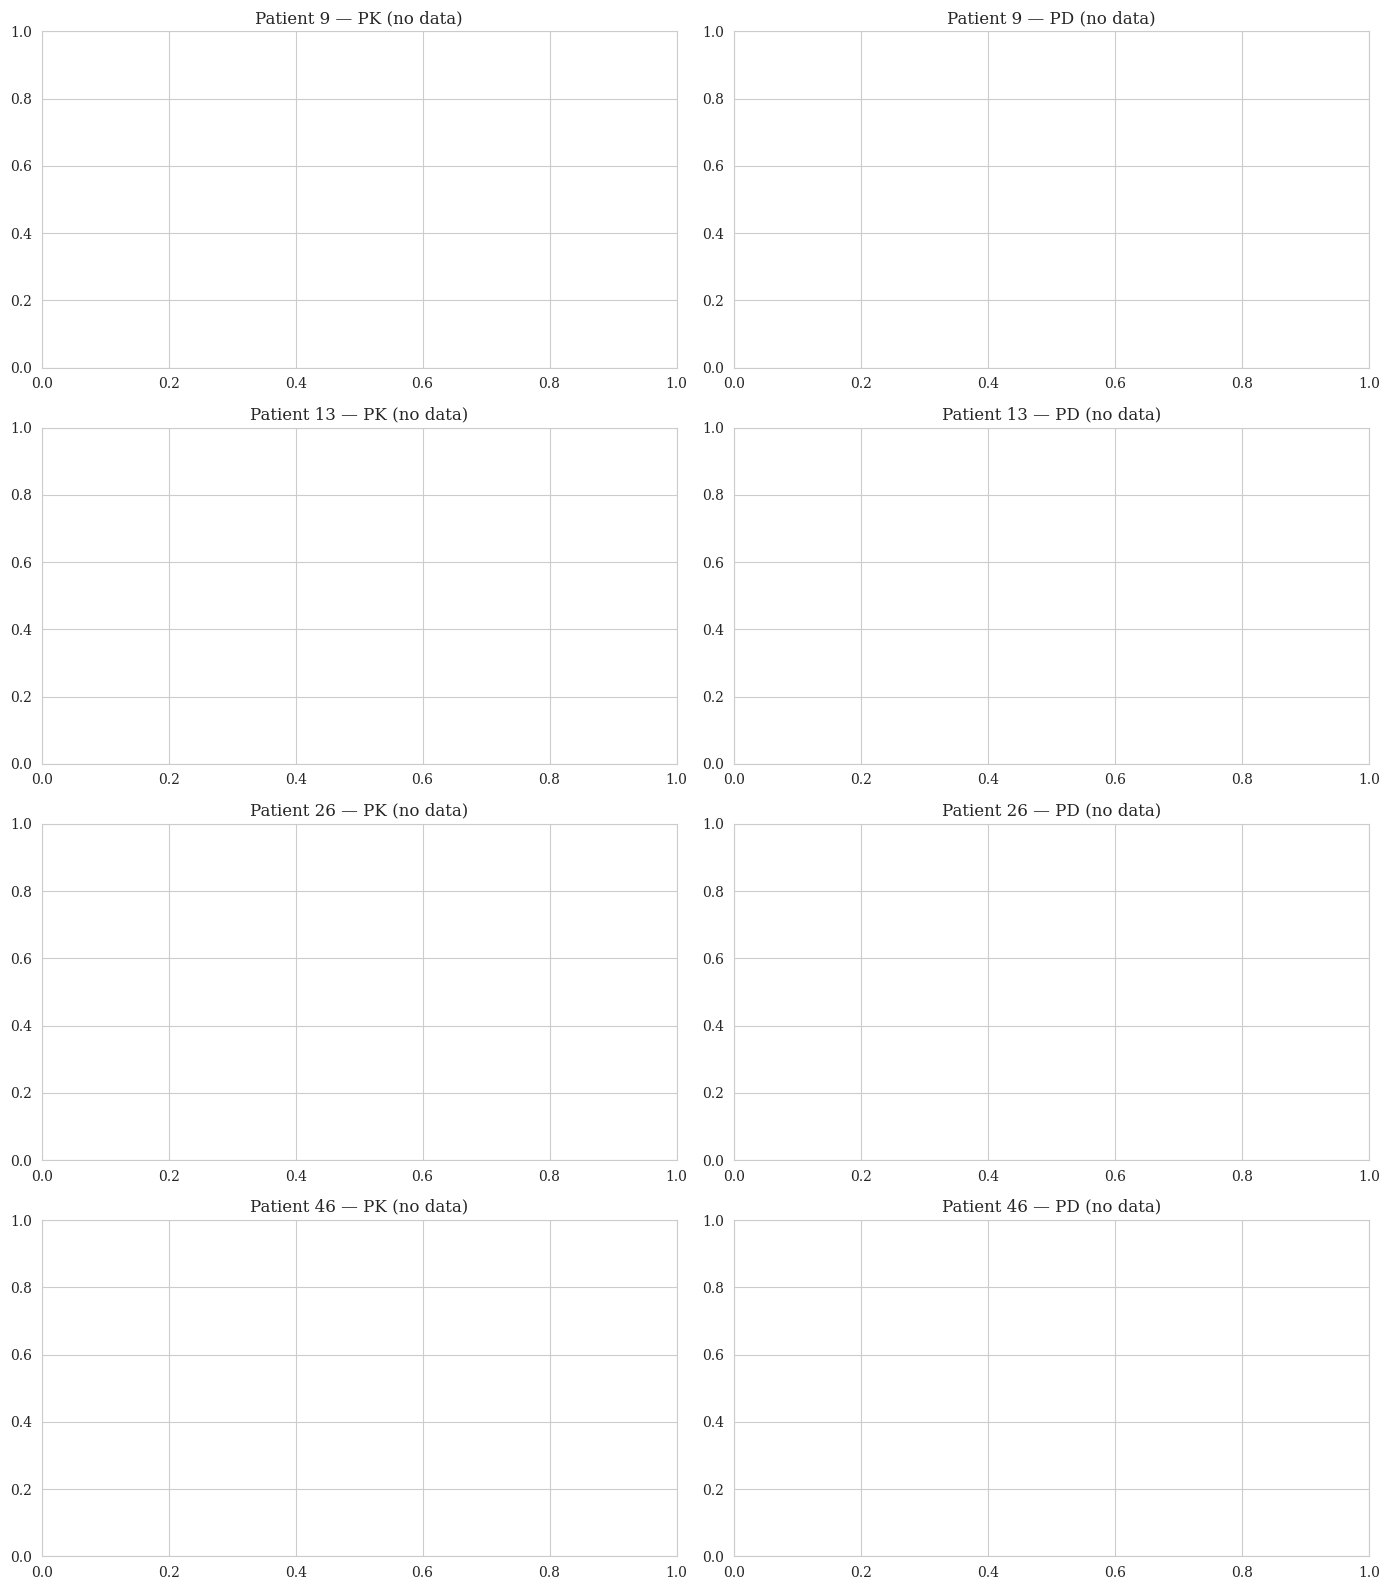

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm", "font.size": 10})


def plot_patient_comparison(patient_ids, all_results, save_path=None):
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(n_patients, 2, figsize=(14, 4 * n_patients), squeeze=False)

    colors = {"Ideal": "#2196F3", "Aer": "#4CAF50", "FakeTorino": "#FF9800"}
    if any("Real" in k for k in all_results):
        real_key = [k for k in all_results if "Real" in k][0]
        colors[real_key] = "#F44336"

    for row, pid in enumerate(patient_ids):
        for col, (target_type, title) in enumerate([("pk", "PK"), ("pd", "PD")]):
            ax = axes[row, col]

            r0 = list(all_results.values())[0]
            mask = r0[target_type]['ids'] == pid
            if not mask.any():
                ax.set_title(f"Patient {pid} — {title} (no data)")
                continue

            times   = r0[target_type]['times'][mask]
            targets = r0[target_type]['targets'][mask]
            sort_idx = np.argsort(times)
            times, targets = times[sort_idx], targets[sort_idx]

            ax.plot(times, targets, 'ko-', label='Ground Truth', markersize=4, linewidth=1.5)
            for name, res in all_results.items():
                preds = res[target_type]['preds'][mask][sort_idx]
                ax.plot(times, preds, '--', color=colors.get(name, 'gray'),
                        label=name, alpha=0.85, linewidth=1.2)

            ax.set_title(f"Patient {pid} — {title}")
            ax.set_xlabel("Time (h)")
            ax.set_ylabel(f"{title} (DV)")
            if row == 0 and col == 0:
                ax.legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved plot to {save_path}")
    plt.show()


all_results = {
    "Ideal":      results_ideal,
    "Aer":        results_aer,
    "FakeTorino": results_torino,
}
if 'results_real' in dir():
    all_results[f"Real ({real_backend.name})"] = results_real

plot_patient_comparison(
    plot_patient_ids, all_results,
    save_path=f"{res_directory}/ibm_patient_comparison.png",
)


In [55]:
preferred = [9, 13, 26, 46]
available = set(np.unique(results_ideal['pd']['ids']).astype(int).tolist())
plot_patient_ids = [p for p in preferred if p in available]
if len(plot_patient_ids) < 4:
    # bổ sung từ available đến đủ 4
    extras = [p for p in sorted(available) if p not in plot_patient_ids]
    plot_patient_ids += extras[:4 - len(plot_patient_ids)]
print(f"plot_patient_ids → {plot_patient_ids}")


plot_patient_ids → []
